# Retail Demand Forecasting & Sales Planning

## Final Project Summary

This notebook summarizes the complete M5 retail demand forecasting project.

We built forecasting pipelines at four levels:

1. Category level
2. Department level
3. Store level
4. Item level

The goal of this notebook is to compare model performance across forecasting levels, understand where SARIMAX works best, and summarize the final business insights.

In [2]:
import os
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

print("Python executable:")
print(sys.executable)

BASE_DIR = os.path.abspath("..")

OUTPUTS_DIR = os.path.join(BASE_DIR, "outputs")
PROCESSED_DATA_DIR = os.path.join(BASE_DIR, "data", "processed")
MODELS_DIR = os.path.join(BASE_DIR, "models")

print("Base directory:", BASE_DIR)
print("Outputs directory:", OUTPUTS_DIR)

Python executable:
c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\.venv\Scripts\python.exe
Base directory: c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting
Outputs directory: c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\outputs


In [3]:
category_summary_path = os.path.join(
    OUTPUTS_DIR,
    "final_category_forecasting_summary_CA_1.csv"
)

department_summary_path = os.path.join(
    OUTPUTS_DIR,
    "final_department_forecasting_summary_CA_1.csv"
)

store_summary_path = os.path.join(
    OUTPUTS_DIR,
    "final_store_forecasting_summary.csv"
)

item_summary_path = os.path.join(
    OUTPUTS_DIR,
    "final_item_forecasting_summary_top_10_CA_1.csv"
)

category_summary_df = pd.read_csv(category_summary_path)
department_summary_df = pd.read_csv(department_summary_path)
store_summary_df = pd.read_csv(store_summary_path)
item_summary_df = pd.read_csv(item_summary_path)

print("Category summary shape:", category_summary_df.shape)
print("Department summary shape:", department_summary_df.shape)
print("Store summary shape:", store_summary_df.shape)
print("Item summary shape:", item_summary_df.shape)

Category summary shape: (1, 7)
Department summary shape: (1, 10)
Store summary shape: (1, 8)
Item summary shape: (1, 9)


In [4]:
category_summary_df

,store,forecast_level,forecast_horizon_days,final_feature_set,best_foods_mape,best_hobbies_mape,best_household_mape
0,CA_1,category,28,snap_only,4.096004,13.469932,4.964332


In [5]:
department_summary_df

,store,forecast_level,forecast_horizon_days,number_of_departments,final_feature_set,best_department,best_department_mape,weakest_department,weakest_department_mape,average_mape_across_departments
0,CA_1,department,28,7,snap_only,FOODS_3,4.252194,FOODS_1,25.298692,12.972552


In [6]:
store_summary_df

,forecast_level,forecast_horizon_days,number_of_stores,best_store,best_store_mape,weakest_store,weakest_store_mape,average_mape_across_stores
0,store,28,10,CA_1,4.203054,WI_2,9.439917,5.93488


In [7]:
item_summary_df

,store,forecast_level,forecast_horizon_days,number_of_items,best_item,best_item_mape,weakest_item,weakest_item_mape,average_mape_across_items
0,CA_1,item,28,10,FOODS_3_586,17.461578,FOODS_3_120,143.954544,54.129874


## 1. Forecasting Level Comparison

We now combine the final summary from each notebook into one comparison table.

This helps compare how forecasting accuracy changes as we move from aggregated levels to more granular levels.

In [8]:
project_level_summary = []

project_level_summary.append({
    "forecast_level": "category",
    "scope": "CA_1 store categories",
    "number_of_series": 3,
    "best_series": "FOODS",
    "best_mape": category_summary_df["best_foods_mape"].iloc[0],
    "weakest_series": "HOBBIES",
    "weakest_mape": category_summary_df["best_hobbies_mape"].iloc[0],
    "average_mape": np.mean([
        category_summary_df["best_foods_mape"].iloc[0],
        category_summary_df["best_hobbies_mape"].iloc[0],
        category_summary_df["best_household_mape"].iloc[0]
    ])
})

project_level_summary.append({
    "forecast_level": "department",
    "scope": "CA_1 store departments",
    "number_of_series": department_summary_df["number_of_departments"].iloc[0],
    "best_series": department_summary_df["best_department"].iloc[0],
    "best_mape": department_summary_df["best_department_mape"].iloc[0],
    "weakest_series": department_summary_df["weakest_department"].iloc[0],
    "weakest_mape": department_summary_df["weakest_department_mape"].iloc[0],
    "average_mape": department_summary_df["average_mape_across_departments"].iloc[0]
})

project_level_summary.append({
    "forecast_level": "store",
    "scope": "All 10 stores",
    "number_of_series": store_summary_df["number_of_stores"].iloc[0],
    "best_series": store_summary_df["best_store"].iloc[0],
    "best_mape": store_summary_df["best_store_mape"].iloc[0],
    "weakest_series": store_summary_df["weakest_store"].iloc[0],
    "weakest_mape": store_summary_df["weakest_store_mape"].iloc[0],
    "average_mape": store_summary_df["average_mape_across_stores"].iloc[0]
})

project_level_summary.append({
    "forecast_level": "item",
    "scope": "Top 10 CA_1 items",
    "number_of_series": item_summary_df["number_of_items"].iloc[0],
    "best_series": item_summary_df["best_item"].iloc[0],
    "best_mape": item_summary_df["best_item_mape"].iloc[0],
    "weakest_series": item_summary_df["weakest_item"].iloc[0],
    "weakest_mape": item_summary_df["weakest_item_mape"].iloc[0],
    "average_mape": item_summary_df["average_mape_across_items"].iloc[0]
})

project_level_summary_df = pd.DataFrame(project_level_summary)

project_level_summary_df

,forecast_level,scope,number_of_series,best_series,best_mape,weakest_series,weakest_mape,average_mape
0,category,CA_1 store categories,3,FOODS,4.096004,HOBBIES,13.469932,7.510090
1,department,CA_1 store departments,7,FOODS_3,4.252194,FOODS_1,25.298692,12.972552
2,store,All 10 stores,10,CA_1,4.203054,WI_2,9.439917,5.934880
3,item,Top 10 CA_1 items,10,FOODS_3_586,17.461578,FOODS_3_120,143.954544,54.129874


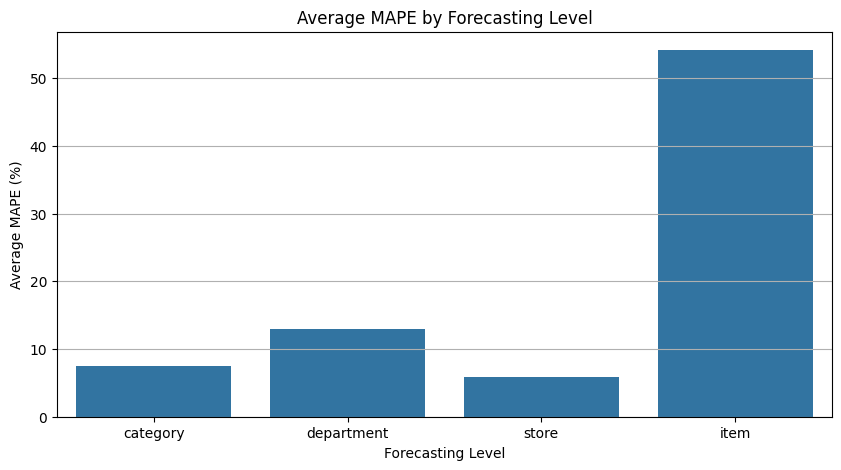

In [9]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=project_level_summary_df,
    x="forecast_level",
    y="average_mape"
)

plt.title("Average MAPE by Forecasting Level")
plt.xlabel("Forecasting Level")
plt.ylabel("Average MAPE (%)")
plt.grid(axis="y")
plt.show()

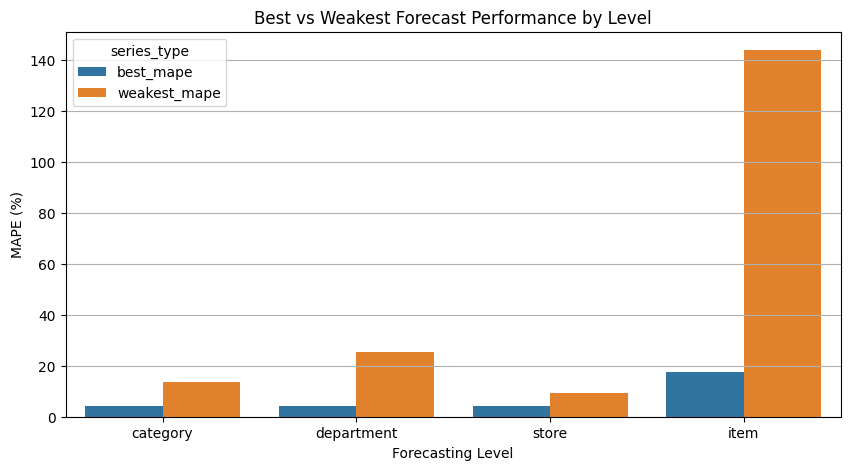

In [10]:
comparison_plot_df = project_level_summary_df.melt(
    id_vars=["forecast_level"],
    value_vars=["best_mape", "weakest_mape"],
    var_name="series_type",
    value_name="MAPE"
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=comparison_plot_df,
    x="forecast_level",
    y="MAPE",
    hue="series_type"
)

plt.title("Best vs Weakest Forecast Performance by Level")
plt.xlabel("Forecasting Level")
plt.ylabel("MAPE (%)")
plt.grid(axis="y")
plt.show()

In [11]:
final_project_summary_path = os.path.join(
    OUTPUTS_DIR,
    "final_project_level_summary.csv"
)

project_level_summary_df.to_csv(
    final_project_summary_path,
    index=False
)

print("Final project-level summary saved to:")
print(final_project_summary_path)

Final project-level summary saved to:
c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\outputs\final_project_level_summary.csv


## 2. Final Business Conclusion

This project built a complete retail demand forecasting workflow using the M5 Walmart dataset.

Forecasting was performed at four levels:

- Store level
- Category level
- Department level
- Item level

The results show that forecasting accuracy depends strongly on the level of aggregation.

### Key Findings

1. Store-level forecasting performed best overall, with an average MAPE of around 5.93%.
2. Category-level forecasting also performed strongly, with an average MAPE of around 7.51%.
3. Department-level forecasting was moderately accurate, with stronger results for high-volume departments and weaker results for low-volume departments.
4. Item-level forecasting was the hardest, with an average MAPE above 50%, due to sparse sales, zero-demand days, and sudden demand spikes.
5. SARIMAX captured weekly seasonality well at aggregated levels, but struggled with irregular product-level demand.

### Modeling Insights

- Aggregated demand is more stable and easier to forecast.
- Low-volume and sparse series require more advanced modeling strategies.
- Calendar features improved some individual cases but did not consistently improve all levels.
- Final model selection should be based on validation performance and convergence stability, not feature complexity.

### Business Recommendations

1. Use store-level forecasts for high-level inventory and staffing planning.
2. Use category-level forecasts for category-level replenishment and sales planning.
3. Use department-level forecasts for more detailed stock allocation.
4. Use item-level SARIMAX only as a baseline, not as the final production model.
5. For item-level forecasting, future improvements should include price, promotions, stock availability, rolling features, and machine learning models such as LightGBM or XGBoost.

In [12]:
recommendations_df = pd.DataFrame([
    {
        "forecast_level": "store",
        "model_reliability": "high",
        "recommended_use": "overall demand planning, staffing, inventory allocation",
        "final_note": "Best performing level due to aggregation stability"
    },
    {
        "forecast_level": "category",
        "model_reliability": "high",
        "recommended_use": "category-level replenishment and sales planning",
        "final_note": "Strong performance for FOODS and HOUSEHOLD"
    },
    {
        "forecast_level": "department",
        "model_reliability": "medium",
        "recommended_use": "department-level stock planning",
        "final_note": "Works well for high-volume departments, weaker for low-volume ones"
    },
    {
        "forecast_level": "item",
        "model_reliability": "low to medium",
        "recommended_use": "baseline item-level forecasting only",
        "final_note": "Needs price, promotion, stockout, and ML-based features"
    }
])

recommendations_df

,forecast_level,model_reliability,recommended_use,final_note
0,store,high,"overall demand planning, staffing, inventory a...",Best performing level due to aggregation stabi...
1,category,high,category-level replenishment and sales planning,Strong performance for FOODS and HOUSEHOLD
2,department,medium,department-level stock planning,"Works well for high-volume departments, weaker..."
3,item,low to medium,baseline item-level forecasting only,"Needs price, promotion, stockout, and ML-based..."


In [13]:
final_recommendations_path = os.path.join(
    OUTPUTS_DIR,
    "final_business_recommendations.csv"
)

recommendations_df.to_csv(
    final_recommendations_path,
    index=False
)

print("Final business recommendations saved to:")
print(final_recommendations_path)

Final business recommendations saved to:
c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\outputs\final_business_recommendations.csv


In [14]:
print("Final project summary notebook completed successfully.")
print()
print("Saved files:")
print("1.", final_project_summary_path)
print("2.", final_recommendations_path)

Final project summary notebook completed successfully.

Saved files:
1. c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\outputs\final_project_level_summary.csv
2. c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\outputs\final_business_recommendations.csv
